In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 20)

In [2]:
DATA_DIR_FILE = "../data/raw/car_price.csv"

df = pd.read_csv(DATA_DIR_FILE)
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [3]:
# Which features are numerical? Which are categorical?

TARGET = ['price']
NUM_COLS = ['mileage', 'tax', 'mpg', 'engineSize']
CAT_COLS = ['model', 'transmission', 'fuelType', 'Make']
DATE_COLS = ['year']
SPLITTING_RANDOM_STATE = 101
TRAINING_RANDOM_STATE = 42

In [4]:
# Because of my TARGET is price, I will drop all raws that have null values
df.dropna(subset=['price'], inplace=True)

# Dropping Duplicates
df.drop_duplicates(subset=df.columns, inplace=True)

### Splitting data to train and test sets

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(labels=TARGET, axis=1)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,  random_state=SPLITTING_RANDOM_STATE)

train_df = pd.concat([X_train, y_train], axis=1)

### Exploring cardinality of Rare Labels

In [6]:
# utily
import pandas as pd

def get_rare_labels_cardinality(
    df: pd.DataFrame,
    threshold: float = 0.05
) -> pd.DataFrame:
    """
    Extract categorical columns and calculate rare labels cardinality.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    threshold : float, default=0.05
        Labels with frequency <= threshold are considered rare.

    Returns
    -------
    pd.DataFrame
        Summary dataframe containing rare label statistics.
    """

    cat_cols = df.select_dtypes(include=["str", "category"]).columns

    results = []

    for col in cat_cols:
        freq = df[col].value_counts(normalize=True, dropna=False)

        rare_labels = freq[freq <= threshold]

        results.append({
            "column": col,
            "n_unique_labels": df[col].nunique(dropna=False),
            "n_rare_labels": len(rare_labels),
            "pct_rare_labels": round(
                len(rare_labels) / max(len(freq), 1),
                4
            ),
            "rare_labels": list(rare_labels.index)
        })

    return pd.DataFrame(results).sort_values(
        by="n_rare_labels",
        ascending=False
    ).reset_index(drop=True)

In [7]:
rare_labels_df = get_rare_labels_cardinality(df=train_df, threshold=0.001)
rare_labels_df

# So The most feature to handel it is "model"

,column,n_unique_labels,n_rare_labels,pct_rare_labels,rare_labels
0,model,144,52,0.3611,"[ GT86, Q8, Tourneo Custom, Grand Tourneo C..."
1,transmission,5,1,0.2000,[Other]
2,fuelType,6,1,0.1667,[Electric]
3,Make,8,0,0.0000,[]


## Exploratory Data Analysis (EDA)

In [8]:
# How many rows and columns does the dataset have?
train_df.info()

<class 'pandas.DataFrame'>
Index: 54769 entries, 12564 to 48569
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         52038 non-null  str    
 1   year          51986 non-null  float64
 2   transmission  51984 non-null  str    
 3   mileage       52045 non-null  float64
 4   fuelType      51987 non-null  str    
 5   tax           51986 non-null  float64
 6   mpg           52063 non-null  float64
 7   engineSize    51989 non-null  float64
 8   Make          51980 non-null  str    
 9   price         54769 non-null  float64
dtypes: float64(6), str(4)
memory usage: 5.8 MB


In [9]:
train_df.describe()

,year,mileage,tax,mpg,engineSize,price
count,51986.000000,52045.000000,51986.000000,52063.000000,51989.000000,54769.000000
mean,2017.079483,23186.671169,116.970434,55.895167,1.637233,16601.075736
std,2.095175,21281.905806,63.931708,17.576235,0.562064,9319.494243
min,1996.000000,1.000000,0.000000,0.300000,0.000000,495.000000
25%,2016.000000,7205.000000,30.000000,47.900000,1.200000,10200.000000
50%,2017.000000,17512.000000,145.000000,55.400000,1.600000,14495.000000
75%,2019.000000,32486.000000,145.000000,62.800000,2.000000,20359.000000
max,2020.000000,323000.000000,580.000000,470.800000,6.600000,145000.000000


In [10]:
# Are there any missing values? How many, and in which columns? 
train_df.isna().sum()

model           2731
year            2783
transmission    2785
mileage         2724
fuelType        2782
tax             2783
mpg             2706
engineSize      2780
Make            2789
price              0
dtype: int64

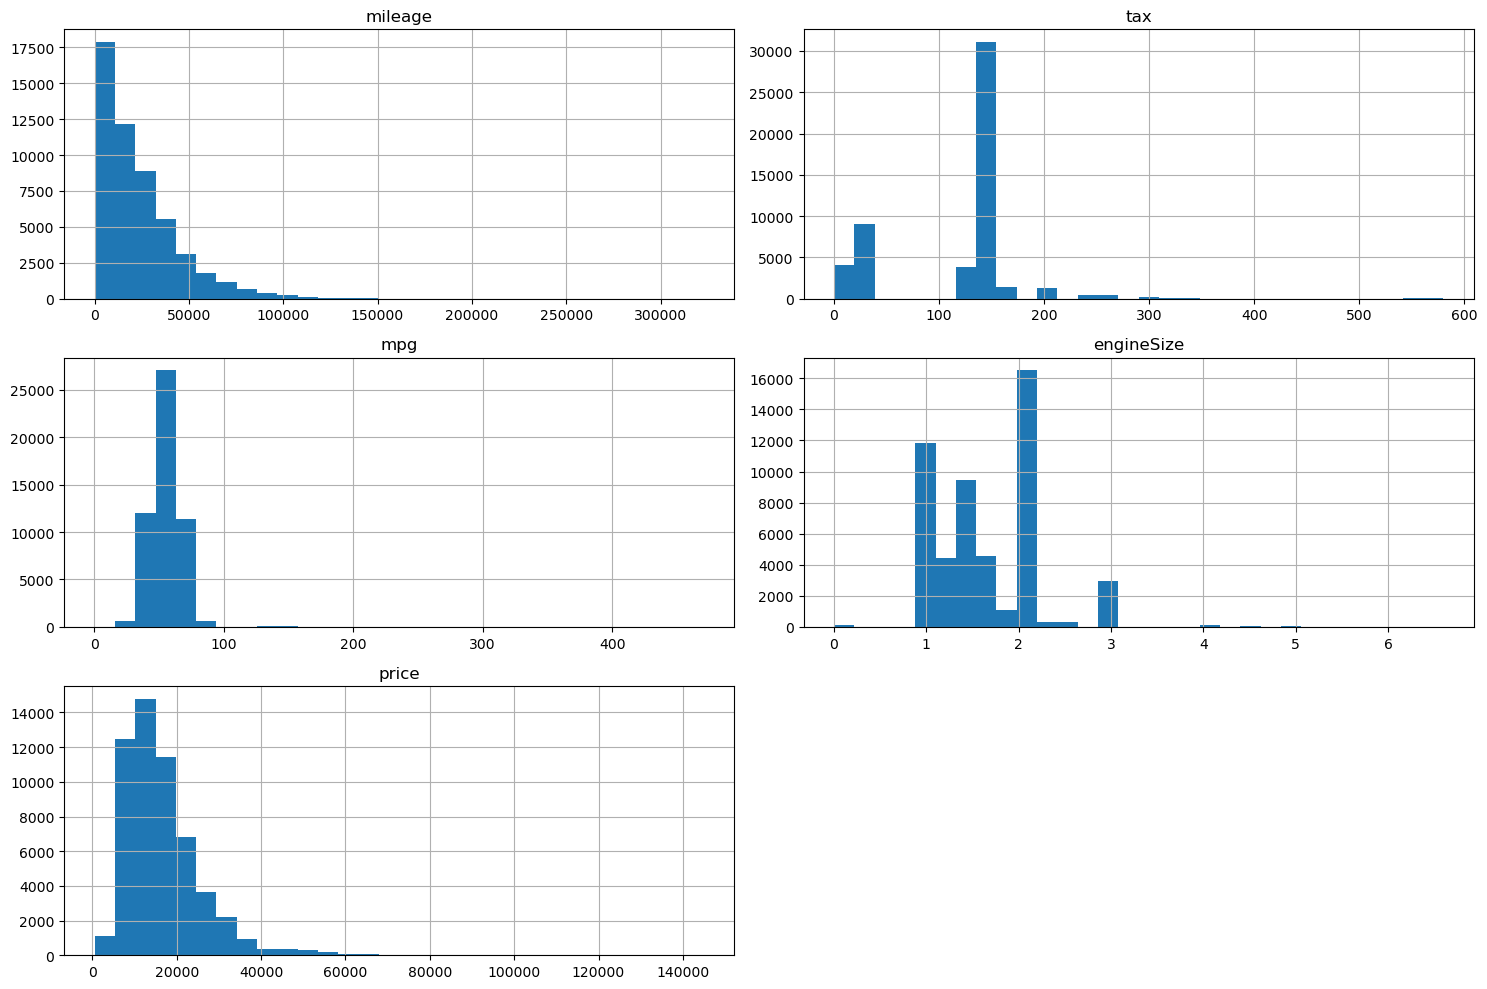

In [11]:
import matplotlib.pyplot as plt

train_df[NUM_COLS + TARGET].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

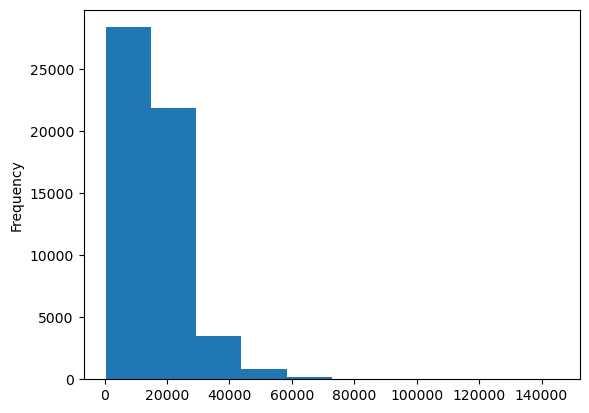

In [12]:
# What does the distribution of car prices look like?
train_df.price.plot(kind='hist')
plt.show()

# So we can see that the distibution of price feature is "right-skewed distribution" 

In [13]:
# Which features seem most related to price?

numeric_corr = train_df.select_dtypes(include=['number']).corr()['price'].drop('price')
print(numeric_corr)

year          0.518655
mileage      -0.426756
tax           0.353164
mpg          -0.326880
engineSize    0.632071
Name: price, dtype: float64


In [14]:
# Which features seem most related to price?

from dython.nominal import associations

df_cat = train_df[CAT_COLS + TARGET].copy()

for col in df_cat.columns:
    df_cat[col] = df_cat[col].fillna("Missing")

assoc_matrix = associations(
    df_cat,
    compute_only=True
)

corr_matrix = assoc_matrix["corr"]
print(corr_matrix["price"].drop('price'))

model           0.773336
transmission    0.514523
fuelType        0.217293
Make            0.455577
Name: price, dtype: float64


## Data Preprocessing & Imputation

In [43]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

import numpy as np
import pandas as pd

def feature_engineering(X):
    X = X.copy()

    # age
    if "year" in X.columns:
        X["age"] = 2026 - X["year"]

    # mileage per year
    if "mileage" in X.columns and "year" in X.columns:
        X["mileage_per_year"] = X["mileage"] / (X["age"] + 1)

    # interaction
    if "engineSize" in X.columns and "mileage" in X.columns:
        X["engine_mileage_interaction"] = X["engineSize"] * X["mileage"]

    X.drop(labels=['year'], axis=1, inplace=True)
    
    return X

feature_engineer = FunctionTransformer(feature_engineering)
    
round_transformer = FunctionTransformer(np.round)
round_transformer_ct = ColumnTransformer(
        transformers=[('round', round_transformer, CAT_COLS)],
        remainder='passthrough',
        verbose_feature_names_out=False
    ).set_output(transform='pandas')

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, StandardScaler

num_transfromer_pipe = Pipeline([
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
]).set_output(transform='pandas')

num_pipe = ColumnTransformer(
    transformers=[
        ('scaler', num_transfromer_pipe, NUM_COLS)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')


In [23]:
# Handling RareLabels
from feature_engine.encoding import RareLabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
import numpy as np

TOL = 0.001
CAT_RARE_LABEL_LIST = ["model"]

rare_encoder = RareLabelEncoder(tol=TOL, variables=CAT_RARE_LABEL_LIST, missing_values="ignore")

cat_pipe = Pipeline([
    ("rare", RareLabelEncoder(tol=0.001, variables=CAT_RARE_LABEL_LIST, missing_values="ignore")),
    ("ore", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan))
]).set_output(transform='pandas')

cat_ct = ColumnTransformer(
    transformers=[
        ('impute_and_encode', cat_pipe, CAT_COLS)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [24]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, NUM_COLS),
        ("cat", cat_pipe, CAT_COLS)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
).set_output(transform="pandas")

In [55]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import FunctionTransformer

rf_imputer = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    max_iter=10,
    random_state=42,
    verbose=2
).set_output(transform='pandas')

impute_pipe = Pipeline([
    ("encode", preprocess),
    ("imputer", rf_imputer),
    ("round_cat", round_transformer_ct),
    ("feature_engineering", feature_engineer)
]).set_output(transform="pandas")



In [56]:
X_train_processed = impute_pipe.fit_transform(X_train, y_train)
X_test_processed = impute_pipe.transform(X_test)

[IterativeImputer] Completing matrix with shape (54769, 9)
[IterativeImputer] Ending imputation round 1/10, elapsed time 10.49
[IterativeImputer] Change: 53.84876900694633, scaled tolerance: 2.02 
[IterativeImputer] Ending imputation round 2/10, elapsed time 20.40
[IterativeImputer] Change: 57.992253327884505, scaled tolerance: 2.02 
[IterativeImputer] Ending imputation round 3/10, elapsed time 30.27
[IterativeImputer] Change: 56.83999999999999, scaled tolerance: 2.02 
[IterativeImputer] Ending imputation round 4/10, elapsed time 40.22
[IterativeImputer] Change: 82.86774288057978, scaled tolerance: 2.02 
[IterativeImputer] Ending imputation round 5/10, elapsed time 50.66
[IterativeImputer] Change: 80.27874139375542, scaled tolerance: 2.02 
[IterativeImputer] Ending imputation round 6/10, elapsed time 62.01
[IterativeImputer] Change: 68.97, scaled tolerance: 2.02 
[IterativeImputer] Ending imputation round 7/10, elapsed time 73.26
[IterativeImputer] Change: 53.5897946906298, scaled tole

/home/mohamedhussam/miniconda3/envs/ml/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[IterativeImputer] Completing matrix with shape (13693, 9)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.76
[IterativeImputer] Ending imputation round 2/10, elapsed time 1.62
[IterativeImputer] Ending imputation round 3/10, elapsed time 3.29
[IterativeImputer] Ending imputation round 4/10, elapsed time 4.18
[IterativeImputer] Ending imputation round 5/10, elapsed time 5.08
[IterativeImputer] Ending imputation round 6/10, elapsed time 5.87
[IterativeImputer] Ending imputation round 7/10, elapsed time 6.86
[IterativeImputer] Ending imputation round 8/10, elapsed time 7.71
[IterativeImputer] Ending imputation round 9/10, elapsed time 8.21
[IterativeImputer] Ending imputation round 10/10, elapsed time 8.87


In [57]:
X_train_processed.head()

,model,transmission,fuelType,Make,mileage,tax,mpg,engineSize,age,mileage_per_year,engine_mileage_interaction
12564,3.0,3.0,0.0,0.0,-0.260870,0.535418,0.790426,0.744045,8.0,-0.028986,-0.194099
50515,76.0,1.0,4.0,6.0,0.655189,0.464686,-0.438694,-0.339190,10.0,0.059563,-0.222233
57706,16.0,0.0,2.0,5.0,-0.355658,-1.971749,1.413048,0.414223,12.0,-0.027358,-0.147322
64078,49.0,3.0,0.0,4.0,-0.994994,0.464686,-0.575237,0.054890,7.0,-0.124374,-0.054615
67392,29.0,1.0,4.0,4.0,0.374965,-1.521620,0.423774,-0.774726,10.0,0.034088,-0.290495


In [58]:
X_train_processed.isna().sum()

model                         0
transmission                  0
fuelType                      0
Make                          0
mileage                       0
tax                           0
mpg                           0
engineSize                    0
age                           0
mileage_per_year              0
engine_mileage_interaction    0
dtype: int64

In [59]:
X_train_processed.head()

,model,transmission,fuelType,Make,mileage,tax,mpg,engineSize,age,mileage_per_year,engine_mileage_interaction
12564,3.0,3.0,0.0,0.0,-0.260870,0.535418,0.790426,0.744045,8.0,-0.028986,-0.194099
50515,76.0,1.0,4.0,6.0,0.655189,0.464686,-0.438694,-0.339190,10.0,0.059563,-0.222233
57706,16.0,0.0,2.0,5.0,-0.355658,-1.971749,1.413048,0.414223,12.0,-0.027358,-0.147322
64078,49.0,3.0,0.0,4.0,-0.994994,0.464686,-0.575237,0.054890,7.0,-0.124374,-0.054615
67392,29.0,1.0,4.0,4.0,0.374965,-1.521620,0.423774,-0.774726,10.0,0.034088,-0.290495


### Train

In [60]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [61]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    print("Train MAE:", mean_absolute_error(y_train, pred_train))
    print("Test MAE :", mean_absolute_error(y_test, pred_test))
    print("-" * 40)
    print("Test RMSE:", np.sqrt(mean_squared_error(y_test, pred_test)))
    print("Test R2  :", r2_score(y_test, pred_test))

In [62]:
lgbm_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    tree_method="hist"
)

In [63]:
evaluate_model(
    lgbm_model,
    X_train_processed, X_test_processed,
    y_train, y_test
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1718
[LightGBM] [Info] Number of data points in the train set: 54769, number of used features: 11
[LightGBM] [Info] Start training from score 16601.075736
Train MAE: 1069.9125321109684
Test MAE : 1201.580201424956
----------------------------------------
Test RMSE: 1846.5277587289559
Test R2  : 0.9598255230353554


In [64]:
evaluate_model(
    xgb_model,
    X_train_processed, X_test_processed,
    y_train, y_test
)

Train MAE: 1010.3762817382812
Test MAE : 1195.4671630859375
----------------------------------------
Test RMSE: 1848.2933344033895
Test R2  : 0.9597486853599548
